
---

# 1. Loss Function in Deep Learning (Complete Concept)

## Loss Function kya hota hai?

Loss function measure karta hai:

**Model kitna galat predict kar raha hai.**

Simple language me:

Prediction − Actual value = Error
Loss function us error ko mathematically measure karta hai.

Goal of training:
👉 Loss ko **minimize** karna.

Training process:

Input → Prediction → Loss Calculate → Backpropagation → Weights Update

---

# Loss vs Cost Function (Interview Question)

Difference:

Loss Function
Ek single data point ka error.

Cost Function
Pure dataset ka average loss.

Example:

Loss(i) = error of ith sample
Cost = average of all losses

---

# Loss Function Categories

Mainly 2 types:

1 Regression Loss
2 Classification Loss

---

# 2. Loss Function for Regression

Regression me output continuous hota hai.

Example:

* House price prediction
* Salary prediction
* Temperature prediction

Most important loss functions:

MSE
MAE
Huber Loss

---

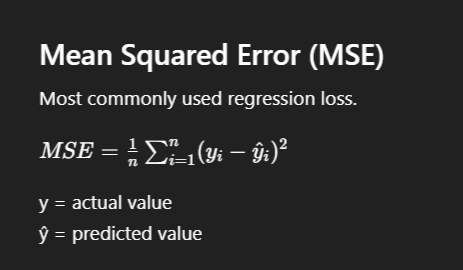
---

## Intuition

Error ko square kar dete hain.

Isliye:

* Large errors ko zyada penalty milti hai.

Example:

Actual = 100
Prediction = 80

Error = 20
Squared error = 400

---

## Advantages

Very popular
Smooth gradient
Works well with gradient descent

---

## Disadvantages (Interview Important)

Sensitive to outliers.

Example:

Ek galat value pura model disturb kar sakta hai.

---

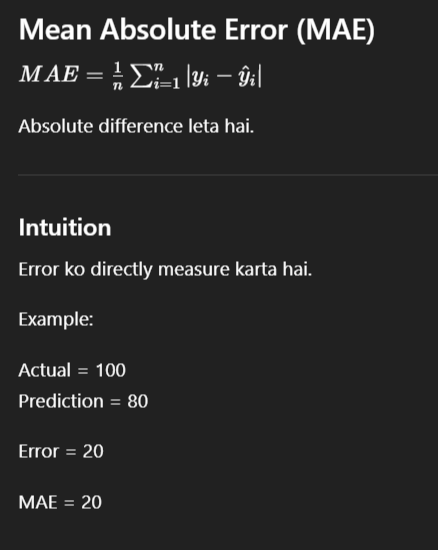

---

## Advantages

Robust to outliers.

---

## Disadvantages

Gradient smooth nahi hota.
Optimization thoda slow ho sakta hai.

Interview line:

"MSE differentiable hai but MAE less sensitive to outliers."

---

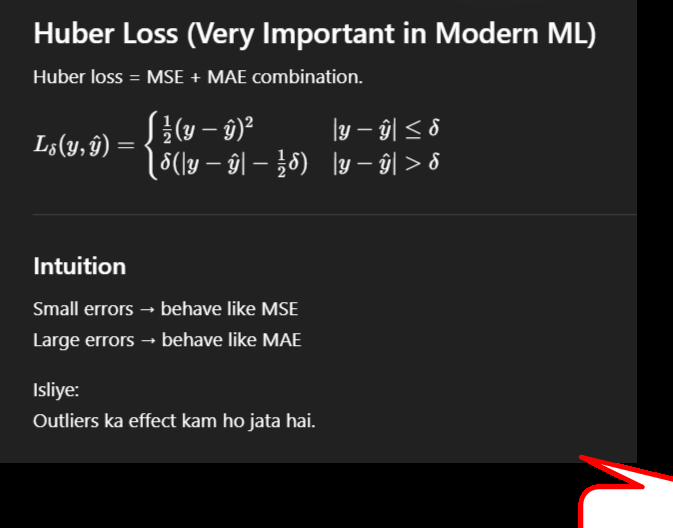
---

## Interview Answer

Best loss when:
Dataset me **outliers ho sakte hain**.

---

# Quick Comparison (Regression Loss)

| Loss  | Outliers  | Gradient   | Use Case           |
| ----- | --------- | ---------- | ------------------ |
| MSE   | Sensitive | Smooth     | Default regression |
| MAE   | Robust    | Not smooth | Noisy data         |
| Huber | Balanced  | Stable     | Real-world ML      |

---

# 3. Loss Function for Classification

Classification me output hota hai:

Class labels.

Example:
Spam vs Not Spam
Cat vs Dog
Multi-class classification

Important losses:

Binary Cross Entropy
Categorical Cross Entropy

---

# Binary Cross Entropy (BCE)

Binary classification ke liye.

Example:
0 or 1 prediction.

L = - \frac{1}{n} \sum_{i=1}^{n} \left[y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i)\right]

---

## Intuition

Agar model wrong confident prediction karta hai
to loss bahut high ho jata hai.

Example:

Actual = 1
Prediction = 0.01

Huge penalty.

---

## Activation Function Used

Sigmoid

Output range:

0 to 1

---

## Interview Trick Question

Q: BCE kab use hota hai?
Answer:

Binary classification + sigmoid output.

---

# Categorical Cross Entropy (CCE)

Multi-class classification ke liye use hota hai.

Example:
Digit classification
ImageNet classification

L = - \sum_{i=1}^{C} y_i \log(\hat{y}_i)

C = number of classes.

---

## Activation Function Used

Softmax

Output example:

Cat → 0.1
Dog → 0.8
Horse → 0.1

---

## Interview Important Point

CCE + Softmax almost always used together.

---

# Binary vs Categorical Cross Entropy

| Feature    | Binary Cross Entropy | Categorical Cross Entropy |
| ---------- | -------------------- | ------------------------- |
| Classes    | 2                    | More than 2               |
| Activation | Sigmoid              | Softmax                   |
| Example    | Spam detection       | Image classification      |

---

# Very Important Interview Question

Why not use MSE for classification?

Answer:

Because:
Cross entropy probability distribution ko better optimize karta hai.

MSE slow convergence deta hai.

---

# Real Training Flow (Deep Learning)

Step-by-step:

1 Input data
2 Model prediction
3 Loss calculate
4 Gradient compute
5 Backpropagation
6 Update weights

Repeat until loss minimum.

---

# Which Loss Function Use Kab Kare?

Regression:
MSE default
MAE noisy data
Huber real-world data

Binary classification:
Binary Cross Entropy

Multi-class classification:
Categorical Cross Entropy

---

# Most Asked Interview Questions

Ye bahut puchte hain:

Difference MSE vs MAE
Cross entropy intuition
Why log used in BCE
Why square error used in MSE
Outliers effect on loss
Relation between loss and gradient descent

---

# Simple Intuition (Memory Trick)

Regression:

Distance measure

Classification:

Probability measure

---

# One-Line Revision (Interview)

Loss function measures prediction error and guides the neural network during training through backpropagation to minimize that error.

---



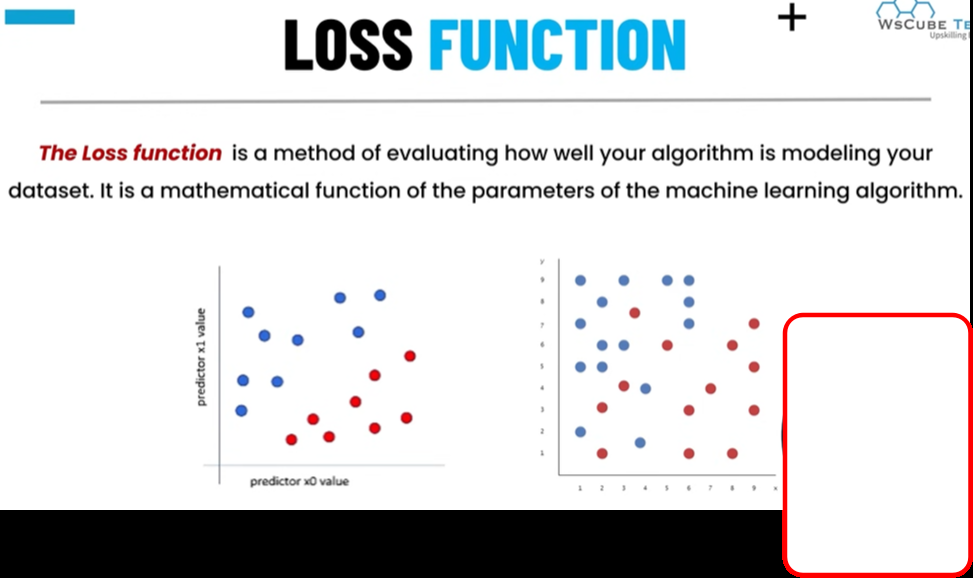

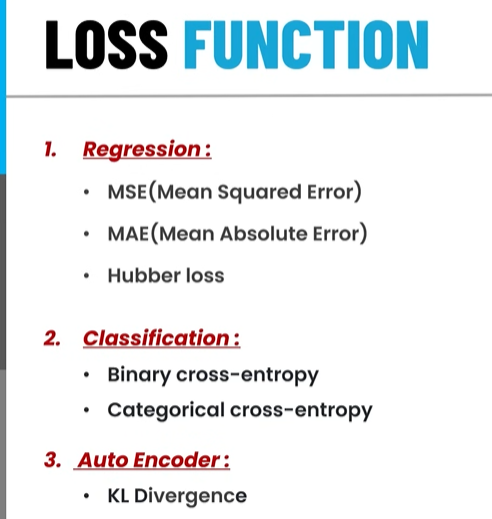

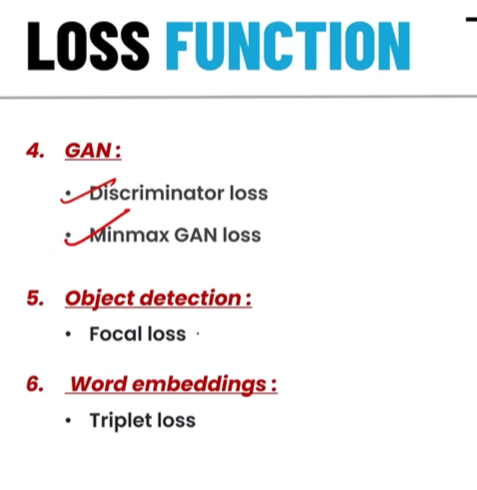

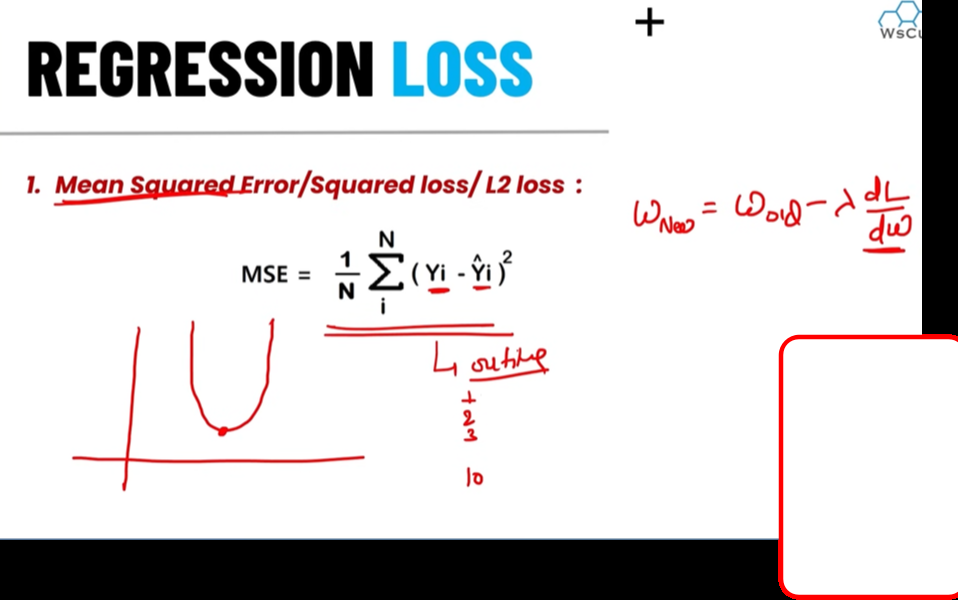

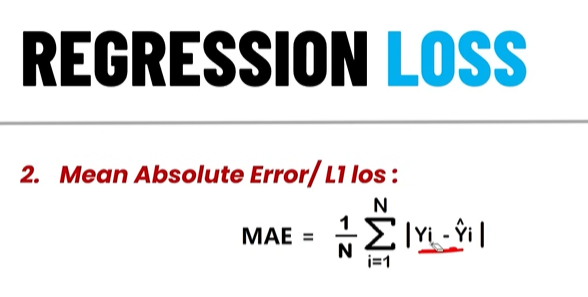

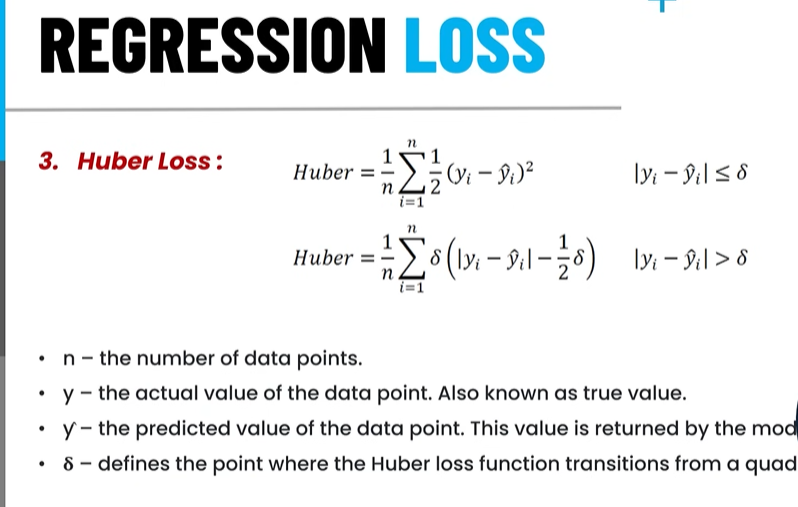

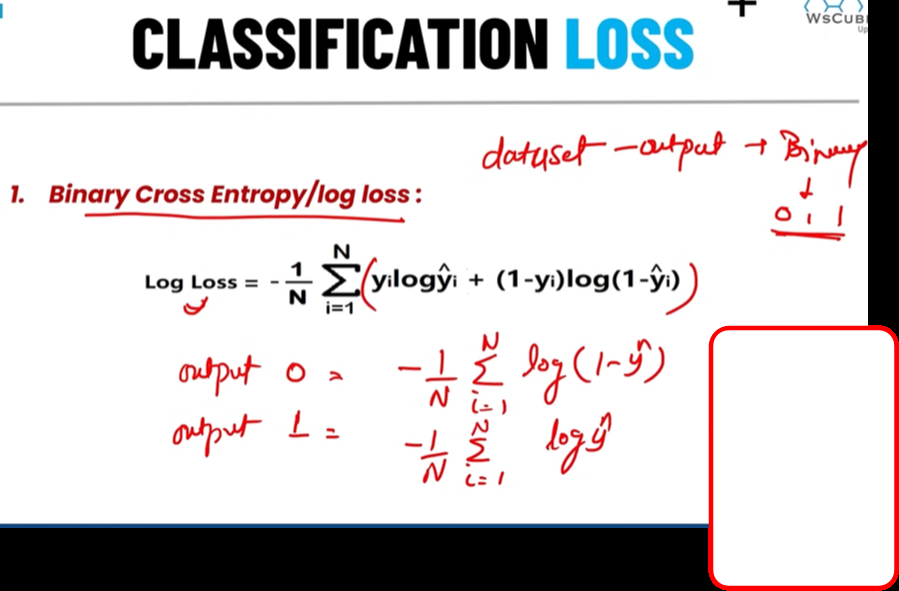

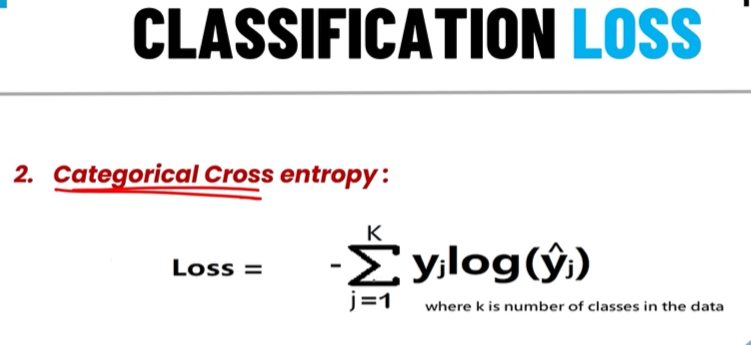

#  Pytorch Implementation:--


Regression Loss Functions

* MSE
* MAE
* Huber Loss

Classification Loss Functions

* Binary Cross Entropy
* Categorical Cross Entropy



Dataset: `ai_practice_dataset.csv`

Columns:

```
cgpa,study_hours,projects,internships,placement_salary,placed,company_type
```

* placement_salary → Regression target
* placed → Binary classification
* company_type → Multi-class classification

---

# 1️⃣ Step 1 — CSV Dataset Generate (Code)

```python
import pandas as pd
import numpy as np

np.random.seed(42)

n = 500

data = {
    "cgpa": np.random.uniform(5, 10, n),
    "study_hours": np.random.uniform(1, 10, n),
    "projects": np.random.randint(0, 6, n),
    "internships": np.random.randint(0, 3, n),
}

df = pd.DataFrame(data)

# regression target
df["placement_salary"] = (
    df["cgpa"] * 5 +
    df["study_hours"] * 2 +
    df["projects"] * 3 +
    df["internships"] * 4 +
    np.random.randn(n) * 2
)

# binary classification
df["placed"] = (df["placement_salary"] > 50).astype(int)

# multi-class classification
conditions = [
    df["placement_salary"] < 45,
    (df["placement_salary"] >= 45) & (df["placement_salary"] < 60),
    df["placement_salary"] >= 60
]

choices = [0,1,2]  # service, product, dream

df["company_type"] = np.select(conditions, choices)

df.to_csv("ai_practice_dataset.csv", index=False)

print("Dataset created")
```

---

# 2️⃣ Load Dataset

```python
import pandas as pd

df = pd.read_csv("ai_practice_dataset.csv")

X = df[["cgpa","study_hours","projects","internships"]].values

y_reg = df["placement_salary"].values.reshape(-1,1)
y_bin = df["placed"].values.reshape(-1,1)
y_multi = df["company_type"].values
```

---

# 3️⃣ Feature Scaling

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)
```

---

# 4️⃣ Simple Neural Network Model

```python
import numpy as np

np.random.seed(1)

input_size = 4
hidden = 8
output_reg = 1

W1 = np.random.randn(input_size, hidden)
b1 = np.zeros((1, hidden))

W2 = np.random.randn(hidden, output_reg)
b2 = np.zeros((1, output_reg))
```

---

# 5️⃣ Activation Function

```python
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1/(1+np.exp(-z))
```

---

# 6️⃣ Forward Propagation

```python
def forward(X):

    global Z1,A1,Z2,A2

    Z1 = np.dot(X,W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1,W2) + b2
    A2 = Z2  # regression output

    return A2
```

---

# 7️⃣ Regression Loss Functions Implementation

## MSE

```python
def mse_loss(y, y_pred):
    return np.mean((y - y_pred)**2)
```

---

## MAE

```python
def mae_loss(y, y_pred):
    return np.mean(np.abs(y - y_pred))
```

---

## Huber Loss

```python
def huber_loss(y, y_pred, delta=1.0):

    error = y - y_pred

    condition = np.abs(error) <= delta

    squared = 0.5 * error**2
    linear = delta * (np.abs(error) - 0.5*delta)

    return np.mean(np.where(condition, squared, linear))
```

---

# 8️⃣ Backpropagation (Regression)

```python
def backward_regression(X, y, y_pred, lr=0.001):

    global W1,W2,b1,b2

    m = len(X)

    dZ2 = (y_pred - y)

    dW2 = np.dot(A1.T, dZ2)/m
    db2 = np.sum(dZ2, axis=0, keepdims=True)/m

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = np.dot(X.T, dZ1)/m
    db1 = np.sum(dZ1, axis=0, keepdims=True)/m

    W2 -= lr*dW2
    b2 -= lr*db2

    W1 -= lr*dW1
    b1 -= lr*db1
```

---

# 9️⃣ Training (Regression)

```python
epochs = 500

for i in range(epochs):

    y_pred = forward(X)

    mse = mse_loss(y_reg, y_pred)
    mae = mae_loss(y_reg, y_pred)
    huber = huber_loss(y_reg, y_pred)

    backward_regression(X, y_reg, y_pred)

    if i % 50 == 0:
        print("Epoch:",i)
        print("MSE:",mse)
        print("MAE:",mae)
        print("Huber:",huber)
```

---

# 🔟 Binary Cross Entropy Implementation

Binary classification network

```python
W2_bin = np.random.randn(hidden,1)
b2_bin = np.zeros((1,1))
```

Forward

```python
def forward_binary(X):

    global Z1,A1,Z2,A2

    Z1 = np.dot(X,W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1,W2_bin) + b2_bin
    A2 = sigmoid(Z2)

    return A2
```

---

## Binary Cross Entropy Loss

```python
def binary_cross_entropy(y, y_pred):

    m = len(y)

    loss = -(1/m)*np.sum(
        y*np.log(y_pred+1e-9) +
        (1-y)*np.log(1-y_pred+1e-9)
    )

    return loss
```

---

# Binary Training

```python
for epoch in range(300):

    y_pred = forward_binary(X)

    loss = binary_cross_entropy(y_bin, y_pred)

    if epoch % 50 == 0:
        print("Epoch:",epoch,"Loss:",loss)
```

---

# 1️⃣1️⃣ Categorical Cross Entropy Implementation

Multi-class classification

Classes:

```
0 service
1 product
2 dream
```

One hot encoding

```python
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(sparse=False)
y_multi_oh = enc.fit_transform(y_multi.reshape(-1,1))
```

---

Softmax

```python
def softmax(z):

    exp = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)
```

---

Forward

```python
W2_multi = np.random.randn(hidden,3)
b2_multi = np.zeros((1,3))

def forward_multi(X):

    global Z1,A1,Z2,A2

    Z1 = np.dot(X,W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1,W2_multi) + b2_multi
    A2 = softmax(Z2)

    return A2
```

---

Categorical Cross Entropy

```python
def categorical_cross_entropy(y_true, y_pred):

    m = len(y_true)

    loss = -np.sum(y_true * np.log(y_pred + 1e-9)) / m

    return loss
```

---

Training

```python
for epoch in range(300):

    y_pred = forward_multi(X)

    loss = categorical_cross_entropy(y_multi_oh, y_pred)

    if epoch % 50 == 0:
        print("Epoch:",epoch,"Loss:",loss)
```

---

# 🎯 Real Deep Learning Version (PyTorch)

Industry level training.

```python
import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(4,16),
    nn.ReLU(),
    nn.Linear(16,8),
    nn.ReLU(),
    nn.Linear(8,1)
)

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
```

Training

```python
X_tensor = torch.tensor(X).float()
y_tensor = torch.tensor(y_reg).float()

for epoch in range(200):

    pred = model(X_tensor)

    loss = loss_fn(pred, y_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(epoch, loss.item())
```

---

# If you really want **Deep Learning mastery** 🚀

Next practical tasks I recommend:

Implement yourself:

```
Loss Function Visualization
Gradient Checking
Custom Optimizer (Adam from scratch)
Learning Rate Scheduler
Batch Training
Mini Batch Gradient Descent
```

---



# Now TensorFlow Implementation:--



---

# 1️⃣ Step 1 — Dataset Create (CSV)

```python
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

data = {
    "cgpa": np.random.uniform(5,10,n),
    "study_hours": np.random.uniform(1,10,n),
    "projects": np.random.randint(0,6,n),
    "internships": np.random.randint(0,3,n)
}

df = pd.DataFrame(data)

df["salary"] = (
    df["cgpa"]*6 +
    df["study_hours"]*2 +
    df["projects"]*3 +
    df["internships"]*5 +
    np.random.randn(n)*3
)

df["placed"] = (df["salary"] > 60).astype(int)

conditions = [
    df["salary"] < 55,
    (df["salary"] >= 55) & (df["salary"] < 70),
    df["salary"] >= 70
]

df["company_type"] = np.select(conditions,[0,1,2])

df.to_csv("deep_learning_dataset.csv",index=False)

print("Dataset Created")
```

---

# 2️⃣ Load Dataset

```python
import pandas as pd

df = pd.read_csv("deep_learning_dataset.csv")

X = df[["cgpa","study_hours","projects","internships"]]

y_reg = df["salary"]
y_bin = df["placed"]
y_multi = df["company_type"]
```

---

# 3️⃣ Feature Scaling

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)
```

---

# 4️⃣ Train Test Split

```python
from sklearn.model_selection import train_test_split

X_train,X_test,y_reg_train,y_reg_test = train_test_split(
    X,y_reg,test_size=0.2,random_state=42
)
```

---

# 5️⃣ Import TensorFlow

```python
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
```

---

# 6️⃣ Neural Network Model (MLP)

```python
def create_model(output_units=1, activation_output=None):

    model = Sequential([
        layers.Dense(32, activation='relu', input_shape=(4,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(output_units, activation=activation_output)
    ])

    return model
```

---

# 7️⃣ Regression — MSE Loss

```python
model_mse = create_model()

model_mse.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_mse = model_mse.fit(
    X_train,
    y_reg_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)
```

---

# 8️⃣ Regression — MAE Loss

```python
model_mae = create_model()

model_mae.compile(
    optimizer='adam',
    loss='mae',
    metrics=['mse']
)

history_mae = model_mae.fit(
    X_train,
    y_reg_train,
    epochs=30,
    batch_size=32
)
```

---

# 9️⃣ Regression — Huber Loss

```python
model_huber = create_model()

model_huber.compile(
    optimizer='adam',
    loss=tf.keras.losses.Huber(),
    metrics=['mae']
)

history_huber = model_huber.fit(
    X_train,
    y_reg_train,
    epochs=30,
    batch_size=32
)
```

---

# 🔟 Binary Classification — Binary Cross Entropy

```python
X_train,X_test,y_bin_train,y_bin_test = train_test_split(
    X,y_bin,test_size=0.2,random_state=42
)

model_binary = create_model(1,'sigmoid')

model_binary.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_binary = model_binary.fit(
    X_train,
    y_bin_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)
```

---

# 1️⃣1️⃣ Multi-Class Classification

One Hot Encoding

```python
from tensorflow.keras.utils import to_categorical

y_multi_encoded = to_categorical(y_multi, num_classes=3)

X_train,X_test,y_multi_train,y_multi_test = train_test_split(
    X,y_multi_encoded,test_size=0.2,random_state=42
)
```

---

# 1️⃣2️⃣ Model — Softmax Output

```python
model_multi = create_model(3,'softmax')

model_multi.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_multi = model_multi.fit(
    X_train,
    y_multi_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)
```

---

# 1️⃣3️⃣ Evaluate Models

```python
print("MSE Model")
model_mse.evaluate(X_test,y_reg_test)

print("MAE Model")
model_mae.evaluate(X_test,y_reg_test)

print("Huber Model")
model_huber.evaluate(X_test,y_reg_test)

print("Binary Model")
model_binary.evaluate(X_test,y_bin_test)

print("Multi Class Model")
model_multi.evaluate(X_test,y_multi_test)
```

---

# 1️⃣4️⃣ Prediction Example

```python
sample = X_test[:5]

print("Regression Prediction")
print(model_mse.predict(sample))

print("Binary Prediction")
print(model_binary.predict(sample))

print("Multi Class Prediction")
print(model_multi.predict(sample))
```

---

# 1️⃣5️⃣ TensorFlow Custom Loss Implementation (Advanced)

Agar tum **AI engineer level mastery** chahte ho to custom loss khud implement karo.

### Custom MSE

```python
def custom_mse(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))
```

### Custom MAE

```python
def custom_mae(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))
```

### Custom Huber

```python
def custom_huber(y_true, y_pred, delta=1.0):

    error = y_true - y_pred

    condition = tf.abs(error) <= delta

    squared = 0.5 * tf.square(error)
    linear = delta * (tf.abs(error) - 0.5*delta)

    return tf.reduce_mean(tf.where(condition, squared, linear))
```

Use:

```python
model.compile(
    optimizer='adam',
    loss=custom_mse
)
```

---

# Real Deep Learning Practice (Recommended)

Agar tum seriously **Deep Learning Engineer level** practice karna chahte ho to next ye implement karo:

```
Mini Batch Training
Callbacks
Early Stopping
Learning Rate Scheduler
TensorBoard Visualization
Model Checkpoint
```

---

